# Online Retail Customer Retention and RFM Analysis

## Project Overview

This project explores purchasing behaviour for a UK-based online retailer. It examines how often identifiable customers return, how long they take to make a second purchase, which customer groups contribute the most revenue, and how purchasing patterns differ over time and across countries.

The analysis uses positive purchase transactions to study repeat purchasing, monthly cohorts, customer revenue concentration and RFM segments.

## Business Questions

1. How strong is repeat purchasing, and when do customers return after their first observed purchase?

2. Which customers and RFM segments contribute the most positive purchase revenue?

3. How do revenue and purchasing patterns vary over time, across order values and between countries?


## 1. Data Loading and Initial Inspection

In [1]:
from pathlib import Path
from matplotlib.ticker import FuncFormatter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
data_path = Path("Online_Retail.xlsx")
raw_df = pd.read_excel(data_path)


In [3]:
raw_df.shape

(541909, 8)

In [4]:
raw_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


## 2. Data Cleaning and Validation

### Initial Data Quality Check

In [6]:
data_quality_summary = pd.Series({
    "Total rows": len(raw_df),
    "Total columns": raw_df.shape[1],
    "Missing CustomerID": raw_df["CustomerID"].isna().sum(),
    "Missing Description": raw_df["Description"].isna().sum(),
    "Exact duplicate rows": raw_df.duplicated().sum(),
    "Quantity less than or equal to zero": (raw_df["Quantity"] <= 0).sum(),
    "UnitPrice less than or equal to zero": (raw_df["UnitPrice"] <= 0).sum(),
    "Cancelled invoice rows": (
        raw_df["InvoiceNo"].astype(str).str.startswith("C")
    ).sum()
})

data_quality_summary

Total rows                              541909
Total columns                                8
Missing CustomerID                      135080
Missing Description                       1454
Exact duplicate rows                      5268
Quantity less than or equal to zero      10624
UnitPrice less than or equal to zero      2517
Cancelled invoice rows                    9288
dtype: int64

### Cleaning Process

In [7]:
# creating a copy of the dataset
df = raw_df.copy()

cleaning_log = [
    {"Step": "Original dataset", "Rows": len(df)}]

# CustomerID is required for customer-level, retention and RFM analysis
df = df.dropna(subset=["CustomerID"]).copy()
cleaning_log.append({
    "Step": "Removed missing CustomerID",
    "Rows": len(df)})

# Remove completely duplicated transaction rows
df = df.drop_duplicates().copy()
cleaning_log.append({
    "Step": "Removed exact duplicates",
    "Rows": len(df)
})

# Exclude returns, cancellations and invalid quantities
df = df[df["Quantity"] > 0].copy()
cleaning_log.append({
    "Step": "Kept positive quantities",
    "Rows": len(df)
})

# Exclude invalid-price transactions
df = df[df["UnitPrice"] > 0].copy()
cleaning_log.append({
    "Step": "Kept positive UnitPrice",
    "Rows": len(df)
})
# Correct data types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int)

# Calculate revenue for each product-level transaction row
df['Total_price'] = df['Quantity'] * df['UnitPrice']


df = df.reset_index(drop=True)

cleaning_log = pd.DataFrame(cleaning_log)
cleaning_log



,Step,Rows
0,Original dataset,541909
1,Removed missing CustomerID,406829
2,Removed exact duplicates,401604
3,Kept positive quantities,392732
4,Kept positive UnitPrice,392692


### Cleaning Validation

In [8]:
cleaning_validation = pd.Series({
    "Final rows": len(df),
    "Missing values": df.isna().sum().sum(),
    "Exact duplicates": df.duplicated().sum(),
    "Non-positive quantities": (df["Quantity"] <= 0).sum(),
    "Non-positive UnitPrice": (df["UnitPrice"] <= 0).sum(),
    "Cancelled invoice rows": (
        df["InvoiceNo"]
          .astype(str)
          .str.startswith("C")
          .sum()
    ),
    "Distinct orders": df["InvoiceNo"].nunique(),
    "Distinct customers": df["CustomerID"].nunique(),
    "Total revenue": round(df["Total_price"].sum(), 2),
    "Start date": df["InvoiceDate"].min(),
    "End date": df["InvoiceDate"].max()
})

cleaning_validation

Final rows                              392692
Missing values                               0
Exact duplicates                             0
Non-positive quantities                      0
Non-positive UnitPrice                       0
Cancelled invoice rows                       0
Distinct orders                          18532
Distinct customers                        4338
Total revenue                       8887208.89
Start date                 2010-12-01 08:26:00
End date                   2011-12-09 12:50:00
dtype: object

### Cleaning Decisions

Transactions without a CustomerID, exact duplicates, returns, cancellations and invalid prices were removed. CustomerID and InvoiceDate were converted to suitable data types, and `Total_price` was calculated as Quantity × UnitPrice.

The cleaned dataset contains 392,692 transaction lines, 18,532 orders and 4,338 identifiable customers. Revenue reflects positive purchases, not net revenue after returns.


## 3. Core Business KPIs

What are the overall customer, order and positive purchase revenue KPIs?

The core KPIs provide an overall view of customer activity and positive purchase revenue during the observed period.

In [9]:

total_revenue = df["Total_price"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()

average_order_value = total_revenue / total_orders
orders_per_customer = total_orders / total_customers
average_revenue_per_customer = total_revenue / total_customers

kpi_summary = pd.DataFrame({
    "Metric": [
        "Positive Purchase Revenue",
        "Distinct Orders",
        "Distinct Customers",
        "Average Order Value",
        "Average Orders per Customer",
        "Average Revenue per Customer"
    ],
    "Value": [
        f"{total_revenue:,.2f}",
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"{average_order_value:,.2f}",
        f"{orders_per_customer:,.2f}",
        f"{average_revenue_per_customer:,.2f}"
    ]
})

kpi_summary

,Metric,Value
0,Positive Purchase Revenue,"8,887,208.89"
1,Distinct Orders,"18,532"
2,Distinct Customers,"4,338"
3,Average Order Value,479.56
4,Average Orders per Customer,4.27
5,Average Revenue per Customer,"2,048.69"


## 4. Repeat-Purchase Analysis

How do one-time and repeat customers differ in customer share, order contribution and revenue contribution?

A repeat customer is defined as a customer who placed more than one distinct order during the observed period. This measures repeat purchasing, not formal customer retention.

In [10]:

customer_order_counts = (
    df.groupby("CustomerID")["InvoiceNo"]
      .nunique())

one_time_customers = (customer_order_counts == 1).sum()
repeat_customers = (customer_order_counts > 1).sum()

one_time_customer_rate = (
    one_time_customers / total_customers
) * 100

repeat_customer_rate = (
    repeat_customers / total_customers
) * 100

repeat_purchase_summary = pd.DataFrame({
    "Metric": [
        "One-Time Customers",
        "Repeat Customers",
        "One-Time Customer Rate",
        "Repeat-Customer Rate"
    ],
    "Value": [
        f"{one_time_customers:,}",
        f"{repeat_customers:,}",
        f"{one_time_customer_rate:.2f}%",
        f"{repeat_customer_rate:.2f}%"
    ]
})

repeat_purchase_summary

,Metric,Value
0,One-Time Customers,"1,493"
1,Repeat Customers,"2,845"
2,One-Time Customer Rate,34.42%
3,Repeat-Customer Rate,65.58%


### One-Time vs Repeat Customer Comparison

This shows whether repeat customers contribute meaningfully more orders and revenue.

In [11]:
# Assign each customer to a purchase-frequency group

customer_type_map = customer_order_counts.apply(
    lambda order_count: (
        "Repeat Customer" if order_count > 1
        else "One-Time Customer"
    )
)

df["Customer_Type"] = df["CustomerID"].map(customer_type_map)

customer_type_summary = (
    df.groupby("Customer_Type")
      .agg(
          Customers=("CustomerID", "nunique"),
          Orders=("InvoiceNo", "nunique"),
          Revenue=("Total_price", "sum")
      )
      .reset_index()
)

customer_type_summary["Customer Share (%)"] = (
    customer_type_summary["Customers"] / total_customers * 100
)

customer_type_summary["Order Share (%)"] = (
    customer_type_summary["Orders"] / total_orders * 100
)

customer_type_summary["Revenue Share (%)"] = (
    customer_type_summary["Revenue"] / total_revenue * 100
)

customer_type_summary = customer_type_summary.round({
    "Revenue": 2,
    "Customer Share (%)": 2,
    "Order Share (%)": 2,
    "Revenue Share (%)": 2
})

customer_type_summary

,Customer_Type,Customers,Orders,Revenue,Customer Share (%),Order Share (%),Revenue Share (%)
0,One-Time Customer,1493,1493,613989.56,34.42,8.06,6.91
1,Repeat Customer,2845,17039,8273219.33,65.58,91.94,93.09


### Customer Share vs Revenue Share

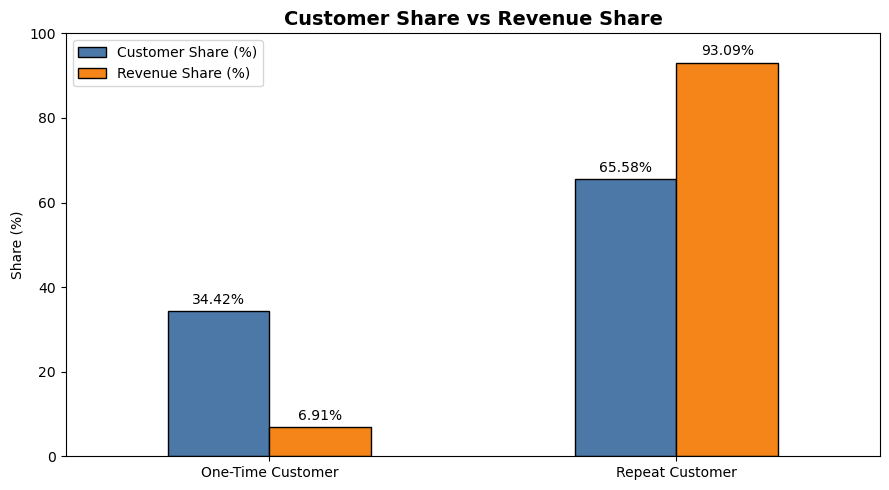

In [12]:
comparison_data = (
    customer_type_summary
    .set_index("Customer_Type")[
        ["Customer Share (%)", "Revenue Share (%)"]
    ]
)

ax = comparison_data.plot(
    kind="bar",
    figsize=(9, 5),
    color=["#4C78A8", "#F58518"],
    edgecolor="black"
)

ax.set_title(
    "Customer Share vs Revenue Share",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("")
ax.set_ylabel("Share (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

### Finding and Business Interpretation

Repeat customers account for 65.58% of identifiable customers but generate 93.09% of positive purchase revenue. In comparison, one-time customers represent 34.42% of customers but contribute only 6.91% of revenue.

This shows that revenue is strongly concentrated among customers who purchased more than once during the observed period. The retailer could protect this revenue base by maintaining engagement with repeat customers while using second-purchase campaigns to encourage suitable one-time customers to return.

## 5. Monthly Cohort Retention Analysis

 How did customers return in the months following their first observed purchase?

Customers are grouped according to their first observed purchase month in the dataset. Retention is then measured by checking whether those customers purchased again in later months.
December 2011 is excluded from the cohort analysis because the dataset contains only a partial month.

### Cohort Preparation

In [13]:
# Exclude incomplete December 2011 from monthly retention analysis

cohort_df = df[
    df["InvoiceDate"] < pd.Timestamp("2011-12-01")
].copy()

# Month in which each transaction occurred
cohort_df["OrderMonth"] = (
    cohort_df["InvoiceDate"].dt.to_period("M")
)

# First observed purchase month for each customer
cohort_df["CohortMonth"] = (
    cohort_df.groupby("CustomerID")["OrderMonth"]
             .transform("min")
)

# Number of months since the customer's first observed purchase
cohort_df["CohortIndex"] = (
    (cohort_df["OrderMonth"].dt.year
     - cohort_df["CohortMonth"].dt.year) * 12
    +
    (cohort_df["OrderMonth"].dt.month
     - cohort_df["CohortMonth"].dt.month)
    + 1
)

# Count distinct active customers by cohort and month number
cohort_counts = (
    cohort_df.groupby(["CohortMonth", "CohortIndex"])
             ["CustomerID"]
             .nunique()
             .unstack())

cohort_counts

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Cohort-Retention Percentages

In [14]:
# Original number of customers in each cohort
cohort_sizes = cohort_counts[1]

# Calculate retention percentage
retention_matrix = (
    cohort_counts.divide(cohort_sizes, axis=0) * 100
)

retention_matrix.round(2)

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,
2010-12,100.0,36.61,32.32,38.42,36.27,39.77,36.27,34.92,35.37,39.55,37.40,50.28
2011-01,100.0,22.06,26.62,23.02,32.13,28.78,24.70,24.22,29.98,32.61,36.45,NaN
2011-02,100.0,18.68,18.68,28.42,27.11,24.74,25.26,27.89,24.74,30.53,NaN,NaN
2011-03,100.0,15.04,25.22,19.91,22.35,16.81,26.77,23.01,27.88,NaN,NaN,NaN
2011-04,100.0,21.33,20.33,21.00,19.67,22.67,21.67,26.00,NaN,NaN,NaN,NaN
2011-05,100.0,19.01,17.25,17.25,20.77,23.24,26.41,NaN,NaN,NaN,NaN,NaN
2011-06,100.0,17.36,15.70,26.45,23.14,33.47,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,100.0,18.09,20.74,22.34,27.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,100.0,20.71,24.85,24.26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Cohort-Retention Heatmap

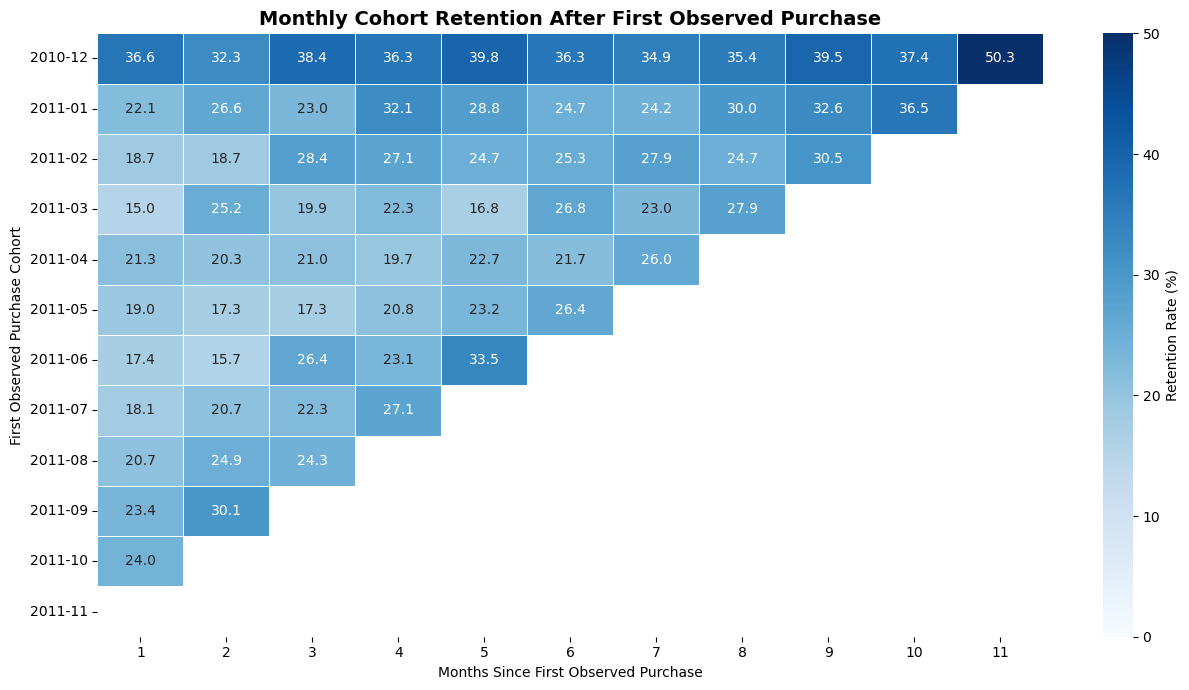

In [15]:

# Exclude the 100% starting month
retention_visual = retention_matrix.iloc[:, 1:].copy()

# Show the actual number of months since the first observed purchase
retention_visual.columns = retention_visual.columns - 1

plt.figure(figsize=(13, 7))

sns.heatmap(
    retention_visual,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    mask=retention_visual.isna(),
    linewidths=0.5,
    vmin=0,
    vmax=50,
    cbar_kws={"label": "Retention Rate (%)"}
)

plt.title(
    "Monthly Cohort Retention After First Observed Purchase",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Months Since First Observed Purchase")
plt.ylabel("First Observed Purchase Cohort")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Retention Insight

For most 2011 cohorts, only around 15% to 24% of customers returned in the following month, showing that the largest drop occurred after the first observed purchase. Some customers returned in later months, so monthly retention did not decline continuously.

The December 2010 cohort performed better, but it may include existing customers whose earlier purchases were not available in the dataset.

### Recommendation

The retailer could focus on encouraging a second purchase within the first one to two months through relevant recommendations, reminders or targeted offers.


## 6. RFM Customer Analysis 

How do customer value and purchasing behaviour differ across RFM segments?



RFM analysis evaluates customers using three observed behaviours:

- **Recency:** Days since the customer’s latest purchase, Lower is better.
- **Frequency:** Number of distinct orders placed, Higher is better.
- **Monetary:** Total positive purchase revenue generated, Higher is better.

In [16]:
# Use one day after the final transaction as the reference date
reference_date = (
    df["InvoiceDate"].max() + pd.Timedelta(days=1))

rfm = (
    df.groupby("CustomerID")
      .agg(
          Recency=(
              "InvoiceDate",
              lambda dates: (
                  reference_date - dates.max()
              ).days
          ),
          Frequency=("InvoiceNo", "nunique"),
          Monetary=("Total_price", "sum")
      )
      .reset_index())

rfm["Monetary"] = rfm["Monetary"].round(2)

print("Reference date:", reference_date)
print("Customers in RFM table:", len(rfm))

rfm.head()

Reference date: 2011-12-10 12:50:00
Customers in RFM table: 4338


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


### RFM Validation

In [17]:

rfm_validation = pd.Series({
    "Customers": len(rfm),
    "Duplicate CustomerIDs": (
        rfm["CustomerID"].duplicated().sum()
    ),
    "Missing RFM values": (
        rfm[["Recency", "Frequency", "Monetary"]]
        .isna()
        .sum()
        .sum()
    ),
    "Negative Recency": (rfm["Recency"] < 0).sum(),
    "Non-positive Frequency": (rfm["Frequency"] <= 0).sum(),
    "Non-positive Monetary": (rfm["Monetary"] <= 0).sum()
})

display(rfm_validation)

display(
    rfm[["Recency", "Frequency", "Monetary"]]
    .describe()
    .round(2)
)

Customers                 4338
Duplicate CustomerIDs        0
Missing RFM values           0
Negative Recency             0
Non-positive Frequency       0
Non-positive Monetary        0
dtype: int64

,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,92.54,4.27,2048.69
std,100.01,7.70,8985.23
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,1660.60
max,374.00,209.00,280206.02


### RFM Scoring Method

Customers are scored from 1 to 4 using the quartiles of each RFM metric.

- For Recency, a lower value receives a higher score.
- For Frequency and Monetary, higher values receive higher scores.
- A score of 4 represents the strongest performance, while 1 represents the weakest.

In [18]:
# Calculate quartile boundaries

r_quartiles = rfm["Recency"].quantile([0.25, 0.50, 0.75])
f_quartiles = rfm["Frequency"].quantile([0.25, 0.50, 0.75])
m_quartiles = rfm["Monetary"].quantile([0.25, 0.50, 0.75])


def recency_score(value):
    if value <= r_quartiles.loc[0.25]:
        return 4
    elif value <= r_quartiles.loc[0.50]:
        return 3
    elif value <= r_quartiles.loc[0.75]:
        return 2
    else:
        return 1


def positive_metric_score(value, quartiles):
    if value <= quartiles.loc[0.25]:
        return 1
    elif value <= quartiles.loc[0.50]:
        return 2
    elif value <= quartiles.loc[0.75]:
        return 3
    else:
        return 4


rfm["R_Score"] = rfm["Recency"].apply(recency_score)

rfm["F_Score"] = rfm["Frequency"].apply(
    lambda value: positive_metric_score(value, f_quartiles)
)

rfm["M_Score"] = rfm["Monetary"].apply(
    lambda value: positive_metric_score(value, m_quartiles)
)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,4,114
1,12347,2,7,4310.00,4,4,4,444
2,12348,75,4,1797.24,2,3,4,234
3,12349,19,1,1757.55,3,1,4,314
4,12350,310,1,334.40,1,1,2,112


### Customer Segmentation

#### Segment Rules

Customers are assigned to one segment using their Recency, Frequency and Monetary scores. The rules are evaluated in order so that every customer receives only one segment.

“At Risk” and “Inactive” describe purchasing behaviour within the observed period. They do not confirm that a customer has permanently churned.

In [19]:
def assign_customer_segment(row):

    if (
        row["R_Score"] == 4
        and row["F_Score"] >= 3
        and row["M_Score"] >= 3
    ):
        return "High-Value Active Customers"

    elif (
        row["R_Score"] >= 3
        and row["F_Score"] >= 3
    ):
        return "Loyal Customers"

    elif (
        row["R_Score"] >= 3
        and row["F_Score"] <= 2
    ):
        return "Potential Loyalists"

    elif (
        row["R_Score"] <= 2
        and row["M_Score"] >= 3
    ):
        return "High-Value At Risk"

    elif row["R_Score"] == 2:
        return "At Risk"

    else:
        return "Inactive Customers"


rfm["Segment"] = rfm.apply(
    assign_customer_segment,
    axis=1
)

rfm[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "R_Score",
        "F_Score",
        "M_Score",
        "RFM_Score",
        "Segment"
    ]
].head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,1,77183.60,1,1,4,114,High-Value At Risk
1,12347,2,7,4310.00,4,4,4,444,High-Value Active Customers
2,12348,75,4,1797.24,2,3,4,234,High-Value At Risk
3,12349,19,1,1757.55,3,1,4,314,Potential Loyalists
4,12350,310,1,334.40,1,1,2,112,Inactive Customers


### Segment Summary

In [20]:
segment_summary = (
    rfm.groupby("Segment")
       .agg(
           Customers=("CustomerID", "nunique"),
           Revenue=("Monetary", "sum"),
           Average_Recency=("Recency", "mean"),
           Average_Frequency=("Frequency", "mean"),
           Average_Monetary=("Monetary", "mean")
       )
       .reset_index()
)

segment_summary["Customer Share (%)"] = (
    segment_summary["Customers"] / len(rfm) * 100
)

segment_summary["Revenue Share (%)"] = (
    segment_summary["Revenue"] / rfm["Monetary"].sum() * 100
)

segment_summary = (
    segment_summary
    .sort_values("Revenue", ascending=False)
    .reset_index(drop=True)
    .round(2)
)

segment_summary

,Segment,Customers,Revenue,Average_Recency,Average_Frequency,Average_Monetary,Customer Share (%),Revenue Share (%)
0,High-Value Active Customers,791,4892817.28,8.01,11.39,6185.61,18.23,55.05
1,Loyal Customers,658,1653299.36,29.06,5.82,2512.61,15.17,18.60
2,High-Value At Risk,715,1370070.39,121.83,3.52,1916.18,16.48,15.42
3,Potential Loyalists,739,537617.83,24.84,1.50,727.49,17.04,6.05
4,Inactive Customers,881,247468.04,253.17,1.34,280.89,20.31,2.78
5,At Risk,554,185935.99,85.65,1.59,335.62,12.77,2.09


### Customer Share vs Revenue Share by Segment

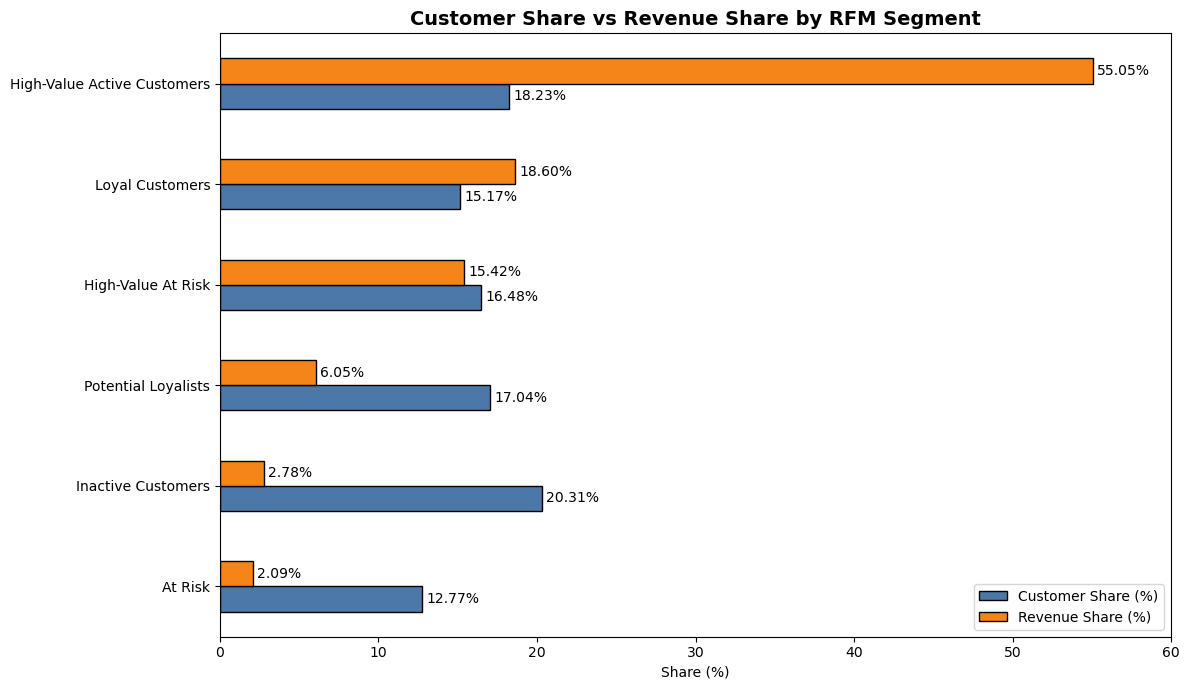

In [21]:
segment_comparison = (
    segment_summary
    .sort_values("Revenue Share (%)")
    .set_index("Segment")[
        ["Customer Share (%)", "Revenue Share (%)"]])

ax = segment_comparison.plot(
    kind="barh",
    figsize=(12, 7),
    color=["#4C78A8", "#F58518"],
    edgecolor="black")

ax.set_title(
    "Customer Share vs Revenue Share by RFM Segment",
    fontsize=14,
    fontweight="bold")

ax.set_xlabel("Share (%)")
ax.set_ylabel("")
ax.set_xlim(0, 60)
ax.legend(title="")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3)

plt.tight_layout()
plt.show()

### Segment Insight

High-Value Active Customers represent 18.23% of customers but generate 55.05% of revenue, making them the most commercially important segment.

High-Value At-Risk customers contribute another 15.42% of revenue, creating an important re-engagement opportunity. Meanwhile, At-Risk and Inactive customers together represent 33.08% of customers but contribute only 4.87% of revenue.




### Recommended Actions by Segment

* **High-Value Active:** Maintain engagement with recognition and relevant communication.
* **Loyal Customers:** Encourage continued purchases through rewards and suitable bundles.
* **Potential Loyalists:** Focus on securing another purchase within the first 60 days.
* **High-Value At Risk:** Use personalised win-back communication and request feedback.
* **At Risk:** Begin with low-cost reminders before offering incentives.
* **Inactive Customers:** Test one reactivation attempt and avoid repeated communication if there is no response.

These recommendations are based on observed behaviour.

## 7. Time to Second Purchase

This analysis measures the number of days between a customer’s first and second observed orders. It includes only customers who placed at least two distinct orders during the dataset period.

In [22]:
# Create one row per customer order

customer_orders = (
    df.groupby(["CustomerID", "InvoiceNo"], as_index=False)
      .agg(Order_Date=("InvoiceDate", "min"))
      .sort_values(
          ["CustomerID", "Order_Date", "InvoiceNo"]))

# Number each customer’s orders chronologically
customer_orders["Order_Number"] = (
    customer_orders.groupby("CustomerID")
                   .cumcount() + 1)

# Keep the first two orders

first_two_orders = (
    customer_orders[
        customer_orders["Order_Number"] <= 2
    ]
    .pivot(
        index="CustomerID",
        columns="Order_Number",
        values="Order_Date"
    )
    .rename(
        columns={
            1: "First_Purchase",
            2: "Second_Purchase"
        })
    .dropna())

# Calculate exact elapsed days

first_two_orders["Days_To_Second_Purchase"] = (
    (
        first_two_orders["Second_Purchase"]
        - first_two_orders["First_Purchase"]
    ).dt.total_seconds() / 86400)

days_to_second = first_two_orders[
    "Days_To_Second_Purchase"
]

second_purchase_summary = pd.DataFrame({
    "Metric": [
        "Customers with a Second Purchase",
        "Average Days to Second Purchase",
        "Median Days to Second Purchase",
        "Returned Within 30 Days",
        "Returned Within 60 Days",
        "Returned Within 90 Days"
    ],
    "Value": [
        f"{len(days_to_second):,}",
        f"{days_to_second.mean():.2f}",
        f"{days_to_second.median():.2f}",
        f"{(days_to_second <= 30).mean() * 100:.2f}%",
        f"{(days_to_second <= 60).mean() * 100:.2f}%",
        f"{(days_to_second <= 90).mean() * 100:.2f}%"
    ]
})

second_purchase_summary

,Metric,Value
0,Customers with a Second Purchase,"2,845"
1,Average Days to Second Purchase,76.70
2,Median Days to Second Purchase,50.12
3,Returned Within 30 Days,33.64%
4,Returned Within 60 Days,55.18%
5,Returned Within 90 Days,67.73%


### Second-Purchase Insight

Among the 2,845 repeat customers, the median time to a second purchase was approximately 50 days. Around 55% returned within 60 days, while approximately 68% returned within 90 days.

The average was higher than the median because some customers took much longer to place their second order.

### Recommendation

The retailer could focus second-purchase reminders and relevant recommendations within the first 60 days, followed by targeted re-engagement before 90 days. The effectiveness of these actions would need to be tested.

## 8. Focused Exploratory Data Analysis

### Monthly revenue and order trend

Monthly revenue and distinct order activity are analysed using complete months only. December 2011 is excluded because the dataset contains only nine days of that month.

In [23]:
# Exclude incomplete December 2011

eda_df = df[
    df["InvoiceDate"] < pd.Timestamp("2011-12-01")
].copy()

eda_df["Month"] = (
    eda_df["InvoiceDate"].dt.to_period("M")
)

monthly_summary = (
    eda_df.groupby("Month")
           .agg(
               Revenue=("Total_price", "sum"),
               Orders=("InvoiceNo", "nunique"),
               Customers=("CustomerID", "nunique")
           )
           .reset_index())

monthly_summary["Revenue"] = (
    monthly_summary["Revenue"].round(2))

monthly_summary

,Month,Revenue,Orders,Customers
0,2010-12,570422.73,1400,885
1,2011-01,568101.31,987,741
2,2011-02,446084.92,997,758
3,2011-03,594081.76,1321,974
4,2011-04,468374.33,1149,856
5,2011-05,677355.15,1555,1056
6,2011-06,660046.05,1393,991
7,2011-07,598962.90,1331,949
8,2011-08,644051.04,1280,935
9,2011-09,950690.20,1755,1266


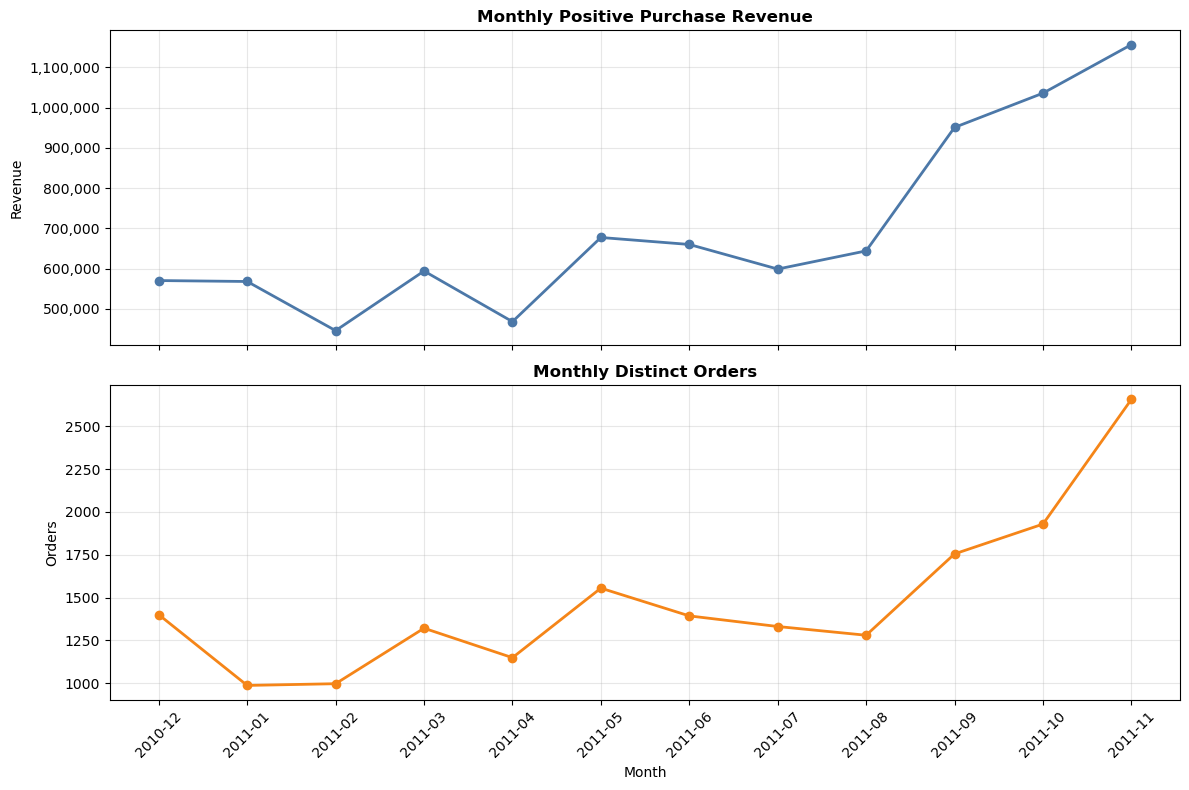

In [24]:
month_labels = monthly_summary["Month"].astype(str)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True
)

# Revenue trend
axes[0].plot(
    month_labels,
    monthly_summary["Revenue"],
    marker="o",
    color="#4C78A8",
    linewidth=2)

axes[0].set_title(
    "Monthly Positive Purchase Revenue",
    fontweight="bold")

axes[0].set_ylabel("Revenue")
axes[0].grid(alpha=0.3)

axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value:,.0f}"))

# Order trend

axes[1].plot(
    month_labels,
    monthly_summary["Orders"],
    marker="o",
    color="#F58518",
    linewidth=2)

axes[1].set_title(
    "Monthly Distinct Orders",
    fontweight="bold")

axes[1].set_xlabel("Month")
axes[1].set_ylabel("Orders")
axes[1].grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Monthly Trend Insight

Revenue and order activity increased noticeably from September to November, with November recording the highest complete-month revenue and order volume.

The similar movement in both measures suggests that the late-period revenue increase was supported by higher purchasing activity. However, one annual cycle is not enough to confirm a recurring seasonal pattern.

### Order-Value Distribution

Order value is calculated by combining all product lines belonging to the same invoice. This helps determine whether the average order value represents a typical order or is influenced by unusually large purchases.

In [25]:
# Create an order-level dataset

order_level = (
    df.groupby(
        ["InvoiceNo", "CustomerID"],
        as_index=False
    )
    .agg(
        Order_Value=("Total_price", "sum"),
        Items=("Quantity", "sum"),
        Order_Date=("InvoiceDate", "min")
    ))

order_value_summary = (
    order_level["Order_Value"]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .round(2))

order_value_summary

count     18532.00
mean        479.56
std        1678.08
min           0.38
25%         157.34
50%         302.58
75%         469.57
90%         820.78
95%        1232.98
99%        3847.79
max      168469.60
Name: Order_Value, dtype: float64

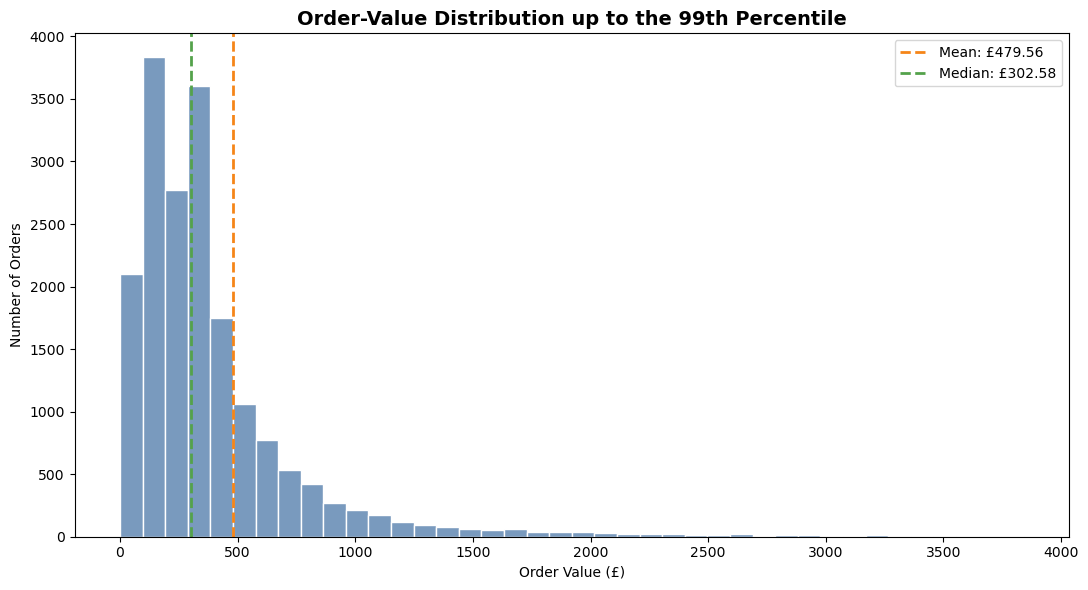

In [26]:
# distribution chart

visual_limit = order_level[
    "Order_Value"
].quantile(0.99)

visual_order_values = order_level[
    order_level["Order_Value"] <= visual_limit
]

mean_order_value = order_value_summary["mean"]
median_order_value = order_value_summary["50%"]

plt.figure(figsize=(11, 6))

sns.histplot(
    visual_order_values["Order_Value"],
    bins=40,
    color="#4C78A8",
    edgecolor="white"
)

plt.axvline(
    mean_order_value,
    color="#F58518",
    linestyle="--",
    linewidth=2,
    label=f"Mean: £{mean_order_value:,.2f}"
)

plt.axvline(
    median_order_value,
    color="#54A24B",
    linestyle="--",
    linewidth=2,
   label=f"Median: £{median_order_value:,.2f}"
)

plt.title(
    "Order-Value Distribution up to the 99th Percentile",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Order Value (£)")
plt.ylabel("Number of Orders")
plt.legend()

plt.tight_layout()
plt.show()

#### Order-Value Insight

Most orders were below £500. The median order value was £302.58, while the average was higher at £479.56 because a small number of very large orders pulled it upward.
This means the average alone does not represent a typical order. The chart hides the top 1% only for readability; those orders are still included in all calculations.


### Customer Revenue Concentration

Customers are ranked by their total positive purchase revenue to measure how much the business depends on its highest-revenue customers.

In [27]:
customer_revenue = (
    df.groupby("CustomerID", as_index=False)
      .agg(Revenue=("Total_price", "sum"))
      .sort_values("Revenue", ascending=False)
      .reset_index(drop=True)
)

customer_revenue["Cumulative Customer Share (%)"] = (
    (customer_revenue.index + 1)
    / len(customer_revenue)
    * 100
)

customer_revenue["Cumulative Revenue Share (%)"] = (
    customer_revenue["Revenue"].cumsum()
    / customer_revenue["Revenue"].sum()
    * 100
)


def revenue_share_from_top(customer_percentage):
    customer_count = int(
        np.ceil(
            len(customer_revenue)
            * customer_percentage
            / 100
        )
    )

    revenue_share = (
        customer_revenue
        .head(customer_count)["Revenue"]
        .sum()
        / customer_revenue["Revenue"].sum()
        * 100
    )

    return revenue_share


top_1_share = revenue_share_from_top(1)
top_5_share = revenue_share_from_top(5)
top_10_share = revenue_share_from_top(10)
top_20_share = revenue_share_from_top(20)

customers_to_80 = (
    customer_revenue[
        "Cumulative Revenue Share (%)"
    ].lt(80).sum() + 1
)

customer_share_to_80 = (
    customers_to_80
    / len(customer_revenue)
    * 100
)

concentration_summary = pd.DataFrame({
    "Metric": [
        "Revenue from Top 1% of Customers",
        "Revenue from Top 5% of Customers",
        "Revenue from Top 10% of Customers",
        "Revenue from Top 20% of Customers",
        "Customers Generating 80% of Revenue"
    ],
    "Value": [
        f"{top_1_share:.2f}%",
        f"{top_5_share:.2f}%",
        f"{top_10_share:.2f}%",
        f"{top_20_share:.2f}%",
        f"{customer_share_to_80:.2f}%"
    ]
})

concentration_summary

,Metric,Value
0,Revenue from Top 1% of Customers,32.06%
1,Revenue from Top 5% of Customers,50.46%
2,Revenue from Top 10% of Customers,61.45%
3,Revenue from Top 20% of Customers,74.68%
4,Customers Generating 80% of Revenue,26.05%


#### Customer-Concentration Insight

The top 10% of customers generated 61.45% of positive purchase revenue, while 26.05% of customers generated 80%.

This shows that revenue depends heavily on a relatively small customer group. The retailer could prioritise engagement with these customers while continuing to develop lower-value and newer customer relationships.


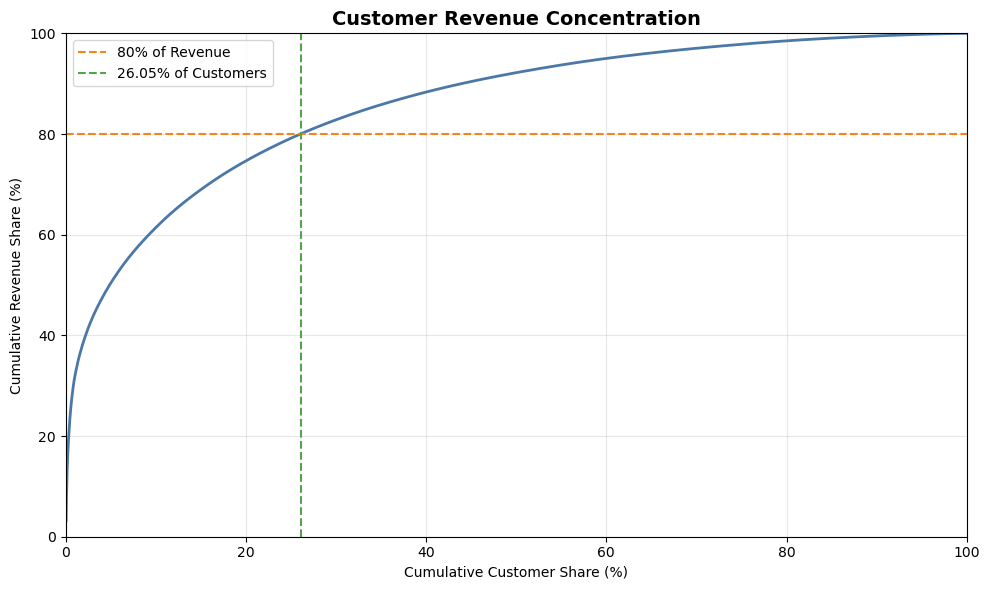

In [28]:
# cumulative concentration 

plt.figure(figsize=(10, 6))

plt.plot(
    customer_revenue[
        "Cumulative Customer Share (%)"
    ],
    customer_revenue[
        "Cumulative Revenue Share (%)"
    ],
    color="#4C78A8",
    linewidth=2
)

plt.axhline(
    80,
    color="#F58518",
    linestyle="--",
    label="80% of Revenue")

plt.axvline(
    customer_share_to_80,
    color="#54A24B",
    linestyle="--",
    label=(
        f"{customer_share_to_80:.2f}% "
        "of Customers"
    )
)

plt.title(
    "Customer Revenue Concentration",
    fontsize=14,
    fontweight="bold")

plt.xlabel("Cumulative Customer Share (%)")
plt.ylabel("Cumulative Revenue Share (%)")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Country-Level Performance

In [29]:
# Country-level summary

country_summary = (
    df.groupby("Country")
      .agg(
          Customers=("CustomerID", "nunique"),
          Orders=("InvoiceNo", "nunique"),
          Revenue=("Total_price", "sum")
      )
      .reset_index()
)

# Calculate each customer's number of orders within each country

country_customer_orders = (
    df.groupby(["Country", "CustomerID"])["InvoiceNo"]
      .nunique()
)

# Percentage of customers with more than one order

repeat_rate = (
    country_customer_orders.gt(1)
      .groupby(level=0)
      .mean()
      .mul(100)
      .rename("Repeat_Customer_Rate_Pct")
)

# Add repeat-customer rate to the country summary

country_summary = country_summary.merge(
    repeat_rate,
    on="Country",
    how="left")

# Calculate each country's share of total revenue

country_summary["Revenue_Share_Pct"] = (
    country_summary["Revenue"]
    / country_summary["Revenue"].sum()
    * 100)

# Sort countries from highest to lowest revenue

country_summary = country_summary.sort_values(
    "Revenue",
    ascending=False)

# Prepare the top 10 countries for display

country_display = country_summary.head(10).copy()

country_display["Revenue"] = country_display["Revenue"].round(2)
country_display["Revenue_Share_Pct"] = (
    country_display["Revenue_Share_Pct"].round(2))

country_display["Repeat_Customer_Rate_Pct"] = (
    country_display["Repeat_Customer_Rate_Pct"].round(2))

display(country_display)

,Country,Customers,Orders,Revenue,Repeat_Customer_Rate_Pct,Revenue_Share_Pct
35,United Kingdom,3920,16646,7285024.64,65.56,81.97
23,Netherlands,9,94,285446.34,55.56,3.21
10,EIRE,3,260,265262.46,100.00,2.98
14,Germany,94,457,228678.40,72.34,2.57
13,France,87,389,208934.31,67.82,2.35
0,Australia,9,57,138453.81,100.00,1.56
30,Spain,30,90,61558.56,63.33,0.69
32,Switzerland,21,51,56443.95,71.43,0.64
3,Belgium,25,98,41196.34,72.00,0.46
31,Sweden,8,36,38367.83,50.00,0.43


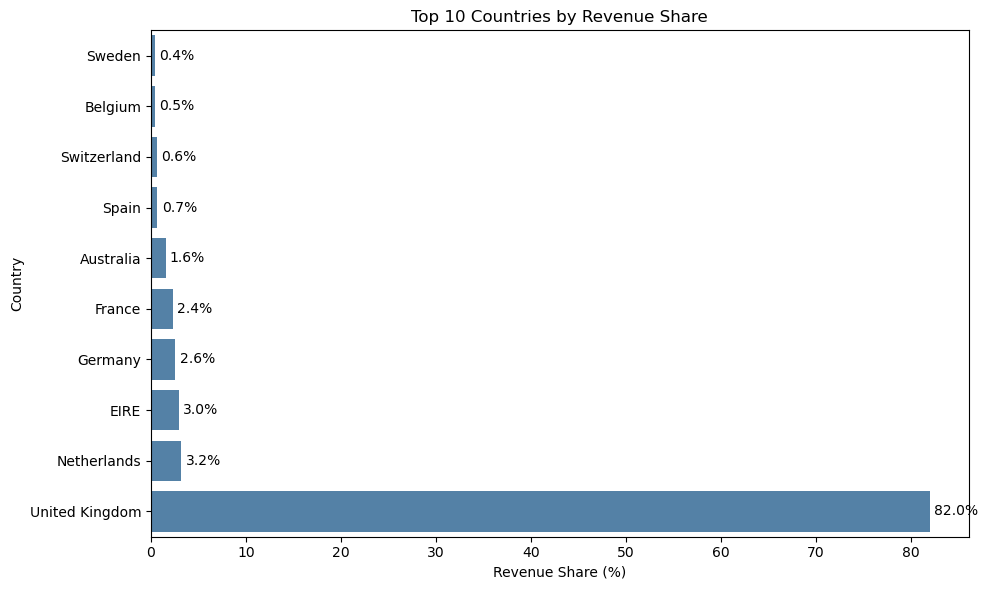

In [30]:
top_countries = (
    country_summary.head(10).sort_values("Revenue_Share_Pct"))

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_countries,
    x="Revenue_Share_Pct",
    y="Country",
    color="steelblue")

plt.title("Top 10 Countries by Revenue Share")
plt.xlabel("Revenue Share (%)")
plt.ylabel("Country")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

#### Country-Level Insight

The United Kingdom generated 81.97% of total revenue, so the overall findings mainly reflect UK customer behaviour. Repeat rates for countries with very few customers should be interpreted cautiously.


## 9. Finding and Limitations

## Findings

* The cleaned data contains 4,338 identifiable customers, 18,532 orders and £8.89 million in positive purchase revenue.
* Repeat customers represent 65.58% of customers and generate 93.09% of revenue.
* The median time to a second purchase is 50 days, with 55.18% returning within 60 days.
* High-Value Active Customers generate 55.05% of revenue. Overall, the top 10% of customers generate 61.45%.
* The United Kingdom generates 81.97% of revenue, so the findings mainly reflect UK customer behaviour.

## Limitations

* Transactions without a CustomerID were removed, so the analysis covers identifiable customers only.
* Returns and cancellations were excluded, revenue represents positive purchases, not net revenue.
* The dataset covers approximately one year, and December 2011 is incomplete.
* Cohorts represent each customer’s first observed purchase, not confirmed acquisition.
* Customers first observed near the end of the dataset had less time to make another purchase, so second-purchase and retention results are affected by the available observation period.
* RFM segments are descriptive groups based on project-specific rules. They do not predict future customer value or confirm that a customer has churned.



## 10. Export Analysis Outputs

### Create an output folder

In [31]:
output_folder = Path("Online retail directory")
output_folder.mkdir(exist_ok=True)

print("Output folder created:", output_folder.resolve())

Output folder created: C:\Users\meghn\Downloads\Online retail directory


### Export cleaned file

In [35]:
output_folder = Path("outputs")
output_folder.mkdir(exist_ok=True)

cleaned_file = output_folder / "clean_online_retail.csv"
rfm_file = output_folder / "rfm_customer_segments.csv"

df.to_csv(cleaned_file, index=False)
rfm.to_csv(rfm_file, index=False)

print(f"Exported cleaned transactions: {cleaned_file}")
print(f"Exported rows: {len(df):,}")
print(f"Exported RFM segments: {rfm_file}")
print(f"Exported customers: {len(rfm):,}")

Exported cleaned transactions: outputs\clean_online_retail.csv
Exported rows: 392,692
Exported RFM segments: outputs\rfm_customer_segments.csv
Exported customers: 4,338
